#One Sample T-test

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:

# Sample data
weights = np.array([42, 39, 48, 60, 41])
mu0 = 48

# Test Normality
shapiro_stat, shapiro_p = stats.shapiro(weights)
print(f"Shapiro-Wilk Test Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Data looks normal (fail to reject H0)")
else:
    print("Data not normal (reject H0)")



Shapiro-Wilk Test Statistic = 0.8442, p-value = 0.1770
Data looks normal (fail to reject H0)


In [ ]:
import numpy as np
from scipy import stats

weights = np.array([42, 39, 48, 60, 41])
mu0 = 48


t_stat, p_value = stats.ttest_1samp(weights, mu0)


t_stat_abs = abs(t_stat)

print(f"|t-statistic|: {t_stat_abs:.4f}")
print(f"p-value: {p_value:.4f}")


alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: mean is significantly different from 48")
else:
    print("Fail to reject the null hypothesis: not enough evidence to say mean differs from 48")


|t-statistic|: 0.5252
p-value: 0.6272
Fail to reject the null hypothesis: not enough evidence to say mean differs from 48


In [ ]:
import numpy as np
from scipy import stats


weights = np.array([42, 39, 48, 60, 41])
mu0 = 48
alpha = 0.05
df = len(weights) - 1


t_stat, p_value = stats.ttest_1samp(weights, mu0)
t_stat_abs = abs(t_stat)


t_critical = stats.t.ppf(1 - alpha/2, df)

print(f"|t-statistic|: {t_stat_abs:.4f}")
print(f"Critical t-value: {t_critical:.4f}")


if t_stat_abs > t_critical:
    print("Reject the null hypothesis: mean is significantly different from 48")
else:
    print("Fail to reject the null hypothesis: not enough evidence to say mean differs from 48")


|t-statistic|: 0.5252
Critical t-value: 2.7764
Fail to reject the null hypothesis: not enough evidence to say mean differs from 48


#Independent sample t-test

In [ ]:
import numpy as np
from scipy import stats

group1 = np.array([18, 20, 36, 50, 49, 36, 34, 49, 41])
group2 = np.array([29, 28, 26, 35, 30, 44, 46])

print("Normality Test (Shapiro–Wilk)")
print("=" * 40)

groups = {"Group 1": group1, "Group 2": group2}

for key, val in groups.items(): #key/val access korte pari
    stat, p = stats.shapiro(val)
    print(f"{key}:")
    print(f"  Statistic = {stat:.4f}")
    print(f"  P-value = {p:.4f}")

    if p > 0.05:
        print("  → Data looks normal (keep H₀)\n")
    else:
        print("  → Data not normal (reject H₀)\n")


Normality Test (Shapiro–Wilk)
Group 1:
  Statistic = 0.8856
  P-value = 0.1795
  → Data looks normal (keep H₀)

Group 2:
  Statistic = 0.8541
  P-value = 0.1340
  → Data looks normal (keep H₀)



In [ ]:
import numpy as np
from scipy import stats


group1 = np.array([18, 20, 36, 50, 49, 36, 34, 49, 41])
group2 = np.array([29, 28, 26, 35, 30, 44, 46])

t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=True)  # Welch's t-test: equal_var=True means:

#We are assuming that both groups have the same population variance (i.e., the spread of marks is roughly equal in both groups).

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")


alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: significant difference exists between group means")
else:
    print("Fail to reject the null hypothesis: no significant difference between group means")


t-statistic: 0.5713
p-value: 0.5768
Fail to reject the null hypothesis: no significant difference between group means


#Paired t-Test

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

before = np.array([36, 40, 38, 36, 42, 38, 40, 46, 58, 62])
after  = np.array([32, 42, 30, 24, 18, 64, 32, 40, 52, 38])

# Step 1: Calculate the differences
diff = before - after
print("Differences:", diff)

# Step 2: Check normality of the differences
shapiro_stat, shapiro_p = stats.shapiro(diff)


print(f"\nShapiro-Wilk Test → Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("✅ Differences look normally distributed (can use paired t-test)")
else:
    print("❌ Differences not normal (should use non-parametric test)")




Differences: [  4  -2   8  12  24 -26   8   6   6  24]

Shapiro-Wilk Test → Statistic = 0.8656, p-value = 0.0888
✅ Differences look normally distributed (can use paired t-test)


In [ ]:
import numpy as np
from scipy import stats


before = np.array([36, 40, 38, 36, 42, 38, 40, 46, 58, 62])
after  = np.array([32, 42, 30, 24, 18, 64, 32, 40, 52, 38])


t_stat, p_value = stats.ttest_rel(before, after)


print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Decision at 5% significance level
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: students have significantly benefited from extra coaching")
else:
    print("Fail to reject the null hypothesis: no significant improvement after coaching")


t-statistic: 1.4381
p-value: 0.1842
Fail to reject the null hypothesis: no significant improvement after coaching


#Anova Test: One Way Anova

In [ ]:
# Test for normality using Shapiro–Wilk test
print("Normality Test (Shapiro–Wilk)")
print("=" * 40)

method_a = np.array([85, 80, 83, 81, 86])
method_b = np.array([78, 82, 80, 79, 81])
method_c = np.array([90, 92, 88, 89, 91])


groups = {
    "Method A": method_a,
    "Method B": method_b,
    "Method C": method_c
}

for keys, values in groups.items():

    stat, p = stats.shapiro(values)

    print(f"{keys}:")
    print(f"  Test Statistic = {stat:.4f}")
    print(f"  P-value = {p:.6f}")

    if p > 0.05:
        print("  → Data seems normal (keep H0)\n")
    else:
        print("  → Data not normal (reject H0)\n")


Normality Test (Shapiro–Wilk)
Method A:
  Test Statistic = 0.9437
  P-value = 0.691856
  → Data seems normal (keep H0)

Method B:
  Test Statistic = 0.9868
  P-value = 0.967174
  → Data seems normal (keep H0)

Method C:
  Test Statistic = 0.9868
  P-value = 0.967174
  → Data seems normal (keep H0)



In [ ]:
import numpy as np
import scipy.stats as stats
import pandas as pd


method_a = np.array([85, 80, 83, 81, 86])
method_b = np.array([78, 82, 80, 79, 81])
method_c = np.array([90, 92, 88, 89, 91])


f_statistic, p_value = stats.f_oneway(method_a, method_b, method_c)


print("ONE-WAY ANOVA RESULTS")
print("=" * 50)
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level (α): 0.05")


if p_value < 0.05:
    print("Decision: REJECT the null hypothesis")
    print("Conclusion: There is a significant difference between the teaching methods.")
else:
    print("Decision: FAIL TO REJECT the null hypothesis")
    print("Conclusion: No significant difference between the teaching methods.")

print("\n" + "=" * 50)
print("GROUP STATISTICS")
print(f"Method A: Mean = {np.mean(method_a):.2f}, Std = {np.std(method_a, ddof=1):.2f}")
print(f"Method B: Mean = {np.mean(method_b):.2f}, Std = {np.std(method_b, ddof=1):.2f}")
print(f"Method C: Mean = {np.mean(method_c):.2f}, Std = {np.std(method_c, ddof=1):.2f}")

ONE-WAY ANOVA RESULTS
F-statistic: 34.3478
P-value: 0.000011
Significance level (α): 0.05
Decision: REJECT the null hypothesis
Conclusion: There is a significant difference between the teaching methods.

GROUP STATISTICS
Method A: Mean = 83.00, Std = 2.55
Method B: Mean = 80.00, Std = 1.58
Method C: Mean = 90.00, Std = 1.58


In [ ]:
import numpy as np
import scipy.stats as stats


method_a = np.array([85, 80, 83, 81, 86])
method_b = np.array([78, 82, 80, 79, 81])
method_c = np.array([90, 92, 88, 89, 91])


all_data = np.concatenate([method_a, method_b, method_c])


mean_a = np.mean(method_a)
mean_b = np.mean(method_b)
mean_c = np.mean(method_c)
grand_mean = np.mean(all_data)


n_a = len(method_a)
n_b = len(method_b)
n_c = len(method_c)
total_n = len(all_data)
k = 3


ssb = (n_a * (mean_a - grand_mean)**2 +
       n_b * (mean_b - grand_mean)**2 +
       n_c * (mean_c - grand_mean)**2)

sst = np.sum((all_data - grand_mean)**2)
ssw = sst - ssb


df_between = k - 1
df_within = total_n - k
df_total = total_n - 1


msb = ssb / df_between
msw = ssw / df_within


f_statistic = msb / msw


f_critical = stats.f.ppf(0.95, df_between, df_within)  # 1 - α = 0.95


p_value = 1 - stats.f.cdf(f_statistic, df_between, df_within)

print("MANUAL CALCULATION - ONE-WAY ANOVA")
print("=" * 60)
print("Sum of Squares:")
print(f"  Between Groups (SSB): {ssb:.2f}")
print(f"  Within Groups (SSW):  {ssw:.2f}")
print(f"  Total (SST):          {sst:.2f}")
print(f"\nDegrees of Freedom:")
print(f"  Between Groups: {df_between}")
print(f"  Within Groups:  {df_within}")
print(f"  Total:          {df_total}")
print(f"\nMean Squares:")
print(f"  Between Groups (MSB): {msb:.4f}")
print(f"  Within Groups (MSW):  {msw:.4f}")
print(f"\nF-statistic: {f_statistic:.4f}")
print(f"Critical F-value (α=0.05): {f_critical:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"\nDecision: {'REJECT H₀' if f_statistic > f_critical else 'FAIL TO REJECT H₀'}")

MANUAL CALCULATION - ONE-WAY ANOVA
Sum of Squares:
  Between Groups (SSB): 263.33
  Within Groups (SSW):  46.00
  Total (SST):          309.33

Degrees of Freedom:
  Between Groups: 2
  Within Groups:  12
  Total:          14

Mean Squares:
  Between Groups (MSB): 131.6667
  Within Groups (MSW):  3.8333

F-statistic: 34.3478
Critical F-value (α=0.05): 3.8853
P-value: 0.000011

Decision: REJECT H₀


Tukey's Honestly Significant Difference (HSD) test is a statistical test used after a significant ANOVA to determine which specific pairs of group means are significantly different from each other.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import numpy as np


data = {
    'score': [85, 80, 83, 81, 86, 78, 82, 80, 79, 81, 90, 92, 88, 89, 91],
    'method': ['A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'C']
}
df = pd.DataFrame(data)


tukey = pairwise_tukeyhsd(endog=df['score'], groups=df['method'], alpha=0.05)

print("TUKEY HSD POST-HOC TEST")
print("=" * 50)
print(tukey)
print("\n" + "=" * 50)
print("INTERPRETATION:")
print("Pairs with 'reject=True' are significantly different.")
print("This tells us exactly which methods differ from each other.")

TUKEY HSD POST-HOC TEST
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -3.0 0.0766 -6.3036  0.3036  False
     A      C      7.0 0.0003  3.6964 10.3036   True
     B      C     10.0    0.0  6.6964 13.3036   True
----------------------------------------------------

INTERPRETATION:
Pairs with 'reject=True' are significantly different.
This tells us exactly which methods differ from each other.


In Tukey’s HSD output, the most important column for deciding whether two groups are significantly different is the p-adj (adjusted p-value) column.

The null hypothesis (H₀) for each pair says:
“There is no significant difference between the means of these two groups.”

The alternative hypothesis (H₁) says:
“There is a significant difference between the means.”

| **Column**         | **Meaning**                                                                                | **Interpretation Example**                                            |
| ------------------ | ------------------------------------------------------------------------------------------ | --------------------------------------------------------------------- |
| `group1`, `group2` | The **two groups** being compared                                                          | e.g., Method A vs Method B                                            |
| `meandiff`         | Difference between the **mean scores** of the two groups (group2 - group1)                 | A vs B → mean(B) − mean(A) = −3 (so A’s mean is higher by 3 points)   |
| `p-adj`            | **Adjusted p-value** after correcting for multiple comparisons                             | If < 0.05 → difference is significant                                 |
| `lower`, `upper`   | The **95% confidence interval** for the mean difference                                    | If this interval **doesn’t include 0**, difference is significant     |
| `reject`           | True/False — whether to **reject the null hypothesis (H₀: means are equal)** for this pair | `True` → means are significantly different; `False` → not significant |


##Covariance

In [ ]:
import numpy as np
import pandas as pd

hours_studied = [2, 4, 6, 8, 10]
exam_score = [50, 55, 65, 70, 80]

#  Using numpy's cov function
cov_matrix = np.cov(hours_studied, exam_score)
print("Covariance Matrix:\n", cov_matrix)
print("Covariance (X,Y):", cov_matrix[0,1])

Covariance Matrix:
 [[ 10.   37.5]
 [ 37.5 142.5]]
Covariance (X,Y): 37.5


Covariance: 37.5


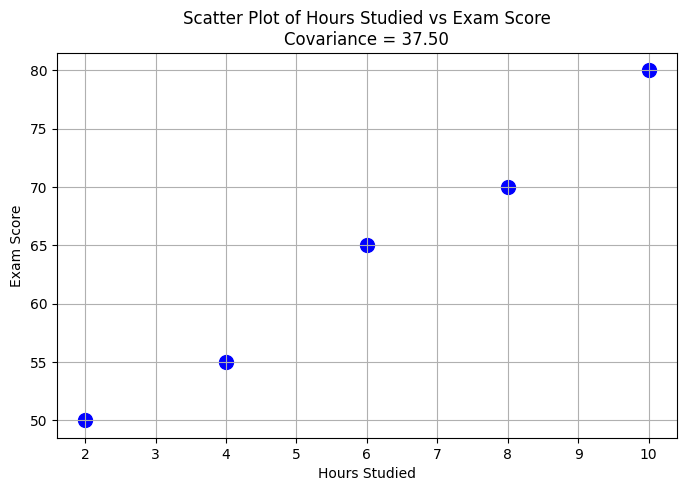

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


hours_studied = [2, 4, 6, 8, 10]
exam_score = [50, 55, 65, 70, 80]


df = pd.DataFrame({'Hours_Studied': hours_studied, 'Exam_Score': exam_score})

cov_value = df['Hours_Studied'].cov(df['Exam_Score'])
print("Covariance:", cov_value)


plt.figure(figsize=(8,5))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='blue', s=100)
plt.title(f"Scatter Plot of Hours Studied vs Exam Score\nCovariance = {cov_value:.2f}")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.grid(True)
plt.show()


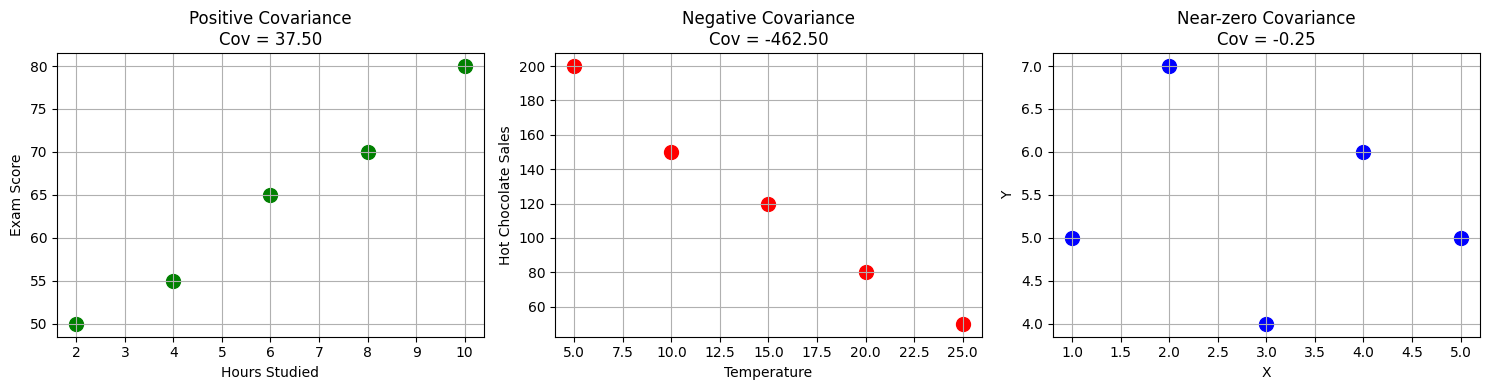

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example 1: Positive Covariance
hours_studied = [2, 4, 6, 8, 10]
exam_score = [50, 55, 65, 70, 80]
df_pos = pd.DataFrame({'X': hours_studied, 'Y': exam_score})
cov_pos = df_pos['X'].cov(df_pos['Y'])

# Example 2: Negative Covariance
temperature = [5, 10, 15, 20, 25]
hot_chocolate_sales = [200, 150, 120, 80, 50]
df_neg = pd.DataFrame({'X': temperature, 'Y': hot_chocolate_sales})
cov_neg = df_neg['X'].cov(df_neg['Y'])

# Example 3: Near-zero Covariance
X = [1, 2, 3, 4, 5]
Y = [5, 7, 4, 6, 5]
df_zero = pd.DataFrame({'X': X, 'Y': Y})
cov_zero = df_zero['X'].cov(df_zero['Y'])

# Plotting all three cases
plt.figure(figsize=(15,4))

# Positive Covariance
plt.subplot(1,3,1)
plt.scatter(df_pos['X'], df_pos['Y'], color='green', s=100)
plt.title(f"Positive Covariance\nCov = {cov_pos:.2f}")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.grid(True)

# Negative Covariance
plt.subplot(1,3,2)
plt.scatter(df_neg['X'], df_neg['Y'], color='red', s=100)
plt.title(f"Negative Covariance\nCov = {cov_neg:.2f}")
plt.xlabel("Temperature")
plt.ylabel("Hot Chocolate Sales")
plt.grid(True)

# Near-zero Covariance
plt.subplot(1,3,3)
plt.scatter(df_zero['X'], df_zero['Y'], color='blue', s=100)
plt.title(f"Near-zero Covariance\nCov = {cov_zero:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.tight_layout()
plt.show()


#Correlation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data
hours_studied = [2, 4, 6, 8, 10]
exam_score = [50, 55, 65, 70, 80]

# Create DataFrame
df = pd.DataFrame({'Hours_Studied': hours_studied, 'Exam_Score': exam_score})

print(df)




   Hours_Studied  Exam_Score
0              2          50
1              4          55
2              6          65
3              8          70
4             10          80


In [ ]:
# Calculate Pearson correlation using built-in function
r = df['Hours_Studied'].corr(df['Exam_Score'])

print(r)


0.9933992677987827


In [ ]:
# Interpretation
if r > 0.5:
    interpretation = "Strong positive linear relationship"
elif r > 0.3:
    interpretation = "Moderate positive linear relationship"
elif r > 0:
    interpretation = "Weak positive linear relationship"
elif r == 0:
    interpretation = "No linear relationship"
elif r > -0.3:
    interpretation = "Weak negative linear relationship"
elif r > -0.5:
    interpretation = "Moderate negative linear relationship"
else:
    interpretation = "Strong negative linear relationship"



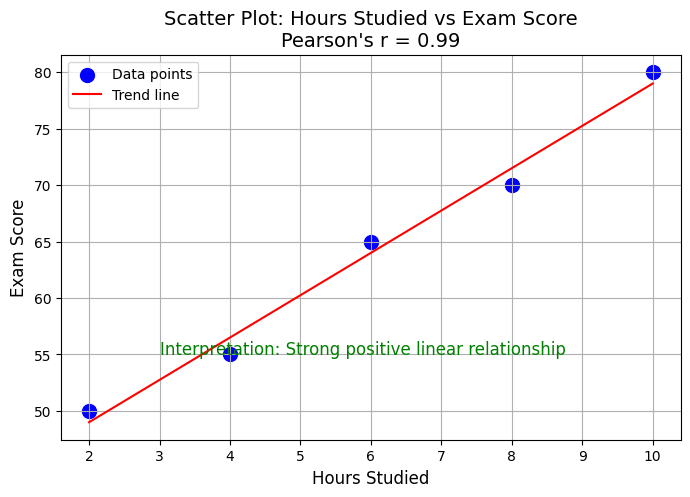

In [ ]:

# --- Scatter plot with trend line ---
plt.figure(figsize=(8,5))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='blue',s=100,  label='Data points')

# Trend line y= mx+c
m, c = np.polyfit(df['Hours_Studied'], df['Exam_Score'], 1)

plt.plot(df['Hours_Studied'], m*np.array(hours_studied)+c, color='red', label='Trend line')

# Titles and labels
plt.title(f"Scatter Plot: Hours Studied vs Exam Score\nPearson's r = {r:.2f}", fontsize=14)
plt.xlabel("Hours Studied", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.legend()
plt.grid(True)

plt.text(3, 55, f"Interpretation: {interpretation}", fontsize=12, color='green')

plt.show()